I need to generate a spite plot of some kind in a manner analogous to the one used previously, such as in Grisoni et al. 2019, which we used in our grant proposal.

So the first order of business is obtaining the actual lithium evolution curve from the paper, which I'll go with Grisoni et al. 2019

Ok, so if I were to implement the models of Grisoni et al. 2019 (or any other modern modeler as far as I can tell), it would be rather labor intensive because I'd basically have to do their modeling again, which would take quite awhile...

It would also require tracking down values that are used from multiple different papers (and private communication) was apparently used at one point as well, so it's still not really possible...

I suppose one does not need a model though if one wants to investigate the primordial lithium abundance, which we should be doing anyway, given our pretty firm ~8 Gyr total age requirement for progenitors and cooling times for all 3 white dwarfs

Anyway, we'll need the solar system meteoritic lithium abundance anyway, so let's use Lodders et al. 2009, from Table 6 of the "recommended present-day solar abundances from photospheric and meteoritic data"

In [1]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from astropy.io import fits
from glob import glob
from astropy.time import Time
from astropy import coordinates as coords
from astropy import units as u
from astropy import constants as const
from astropy import convolution as conv
from astropy.table import Table, Column
import scipy.interpolate as scinterp
import time
start = time.time()

import spec_plot_tools as spt
import cal_params as cp
import plot_spec as ps
import bensby_plotting as bp

print(os.getcwd())

all_avg
/Users/BenKaiser/Desktop/radial_velocity_calculations


In [2]:
target_dir= '/Users/BenKaiser/Desktop/GaiaJ1644m0449_paper/'
os.chdir(target_dir)

In [3]:
wd_abund_file='temp_wd_abundances.csv'
lodders_abund_file='Lodders2009_solarsystem_abundances.csv'

In [4]:
wd_abund_table=Table.read(wd_abund_file)
wd_abund_table.add_index('name')

In [5]:
lodders_table=Table.read(lodders_abund_file)
lodders_table.add_index('element')

In [6]:
print(lodders_table[lodders_table['element']=='Li'])

element A_el A_el_err
------- ---- --------
     Li 3.28     0.05


In [7]:
meteor_Ali= 3.28
meteor_Ali_err= 0.05
meteor_FeH=0.
meteor_FeH_err=0.

In [8]:
#from Mashonkina et al. 2019 and the other Mashonkina et al. 2019/2020 paper that included thin disk stars as well.
npoints=100
FeH_thick= np.linspace(-1.5,-0.4,npoints)
FeH_halo=np.linspace(-2.6,-1.2,npoints)
FeH_thin= np.linspace(-0.73, 0.24, npoints)

In [9]:
#from Mashonkina et al. 2019
CaFe_thick=0.24
CaFe_thick_err=0.07
CaFe_halo=0.35
CaFe_halo_err=0.08

#from later Mashonkina et al. 2019/2020 and our by-eye approximation of the trend
def get_CaFe_thin(FeH):
    slope=(0-0.24)/(0+0.7)
    print(slope)
    return slope*FeH

CaFe_thin=get_CaFe_thin(FeH_thin)

-0.342857142857


We're going to use the Coc et al. 2014 primordial lithium abundance of 2.7 instead of Grisoni's 2.6

https://ui.adsabs.harvard.edu/abs/2014JCAP...10..050C/abstract


It's from the third column of table 1 from that paper (after converting to A(Li)) and technically only counts the Li-7 atoms, but the Li-7 to Li-6 ratio is predicted to be large enough that almost all of the primoridial lithium is Li-7, so good enough

In [10]:
#grisoni_primordial=2.6
grisoni_ALi=2.6
coc_ALi=2.7
primordial_ALi=coc_ALi
def grisoni_crude(FeH):
    """
    return the A(Li) value for the [Fe/H] value using Grisoni et al. 2019 approximated model
    """
    flat_inds= np.where(FeH< -0.71)
    func_inds= np.where(FeH>= -0.71)
    output_array=np.ones(FeH.shape)
    output_array[flat_inds]= primordial_ALi
    output_array[func_inds]= 1.111*(FeH[func_inds]+0.71)+primordial_ALi
    return output_array

In [11]:
def make_plot():
    plt.errorbar(meteor_FeH, meteor_Ali, yerr=meteor_Ali_err, xerr= meteor_FeH_err, label='CI Chond.', marker='o')
    model_FeH= np.linspace(-3, 0.6, 100)
    model_ALi= grisoni_crude(model_FeH)
    plt.plot(model_FeH, model_ALi, label='Crude Grisoni et al. 2019', linestyle='--', color='k')
    plt.xlabel('[Fe/H]')
    plt.ylabel('A(Li)')
    plt.legend(loc='best')
    plt.xlim(-3, 0.6)
    plt.ylim(0,5)
    plt.show()
    return

Mashonkina et al. 2019 do not provide empirical models of their thin disk measurements, presumably because they were trying to obtain thick disk and halo and accidentally got the thin disk objects, so those are most likely the result some sort of biased selection method or something. I need a different source if I want to use those

In [12]:
def LiHe_to_ALi(row,CaFe, FeH, phase='EP'):
    LiCa= row['li/he']-row['ca/he'] #general number, not relative to solar
    if phase=='EP':
        pass
    elif phase=='SSP':
        LiCa=LiCa+row['tau_ca/tau_li']
    #print('Li/Ca', LiCa)
    CaH=CaFe+FeH #relative to solar
    #print('[Ca/H]', CaH)
    #print('lodders A(Ca)',lodders_table['A_el'][np.where(lodders_table['element']=='Ca')])
    CaH=CaH+lodders_table['A_el'][np.where(lodders_table['element']=='Ca')] #CaH now in A(Ca)
    #print('A(Ca)', CaH)
    LiH=LiCa+CaH #puts LiH immediately on the A(Li) scale
    ALi= LiH
    return ALi

In [13]:
LiHe_to_ALi(wd_abund_table[np.where(wd_abund_table['name']=='GaiaJ1644-0449')], CaFe_thick, -0.95)

3.9


In [14]:
print(lodders_table['A_el'][np.where(lodders_table['element']=='Ca')])

A_el
----
6.31


In [15]:
plt.figure(figsize=(10,10))

In [16]:
#plt.errorbar(meteor_FeH, meteor_Ali, yerr=meteor_Ali_err, xerr= meteor_FeH_err, label='Meteoritic', marker='o')
for row in wd_abund_table:
    plt.plot(FeH_thin, LiHe_to_ALi(row, CaFe_thin, FeH_thin), label=row['name']+' thin disk')
for row in wd_abund_table:
    plt.plot(FeH_thick, LiHe_to_ALi(row, CaFe_thick, FeH_thick), label=row['name']+' thick disk')
for row in wd_abund_table:
    plt.plot(FeH_halo, LiHe_to_ALi(row, CaFe_halo, FeH_halo), label=row['name']+' halo')

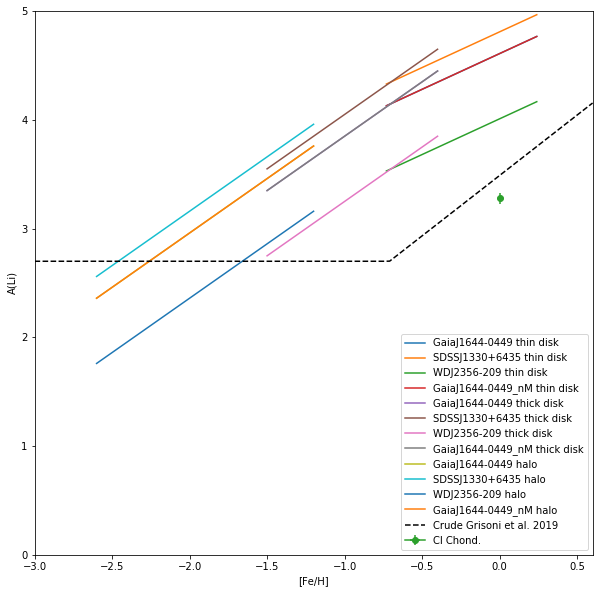

In [17]:
make_plot()

In [18]:
plt.figure(figsize=(10,10))

In [19]:
plt.errorbar(meteor_FeH, meteor_Ali, yerr=meteor_Ali_err, xerr= meteor_FeH_err, label='Meteoritic', marker='o')
for row in wd_abund_table:
    plt.plot(FeH_thick, LiHe_to_ALi(row, CaFe_thick, FeH_thick, phase='SSP'), label=row['name']+' thick disk SSP')
for row in wd_abund_table:
    plt.plot(FeH_halo, LiHe_to_ALi(row, CaFe_halo, FeH_halo, phase='SSP'), label=row['name']+' halo SSP')
for row in wd_abund_table:
    plt.plot(FeH_thin, LiHe_to_ALi(row, CaFe_thin, FeH_thin, phase='SSP'), label=row['name']+' thin disk SSP')

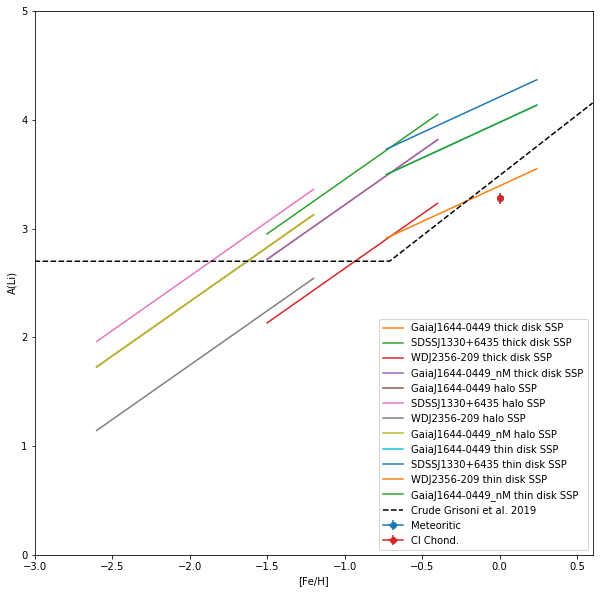

In [20]:
make_plot()

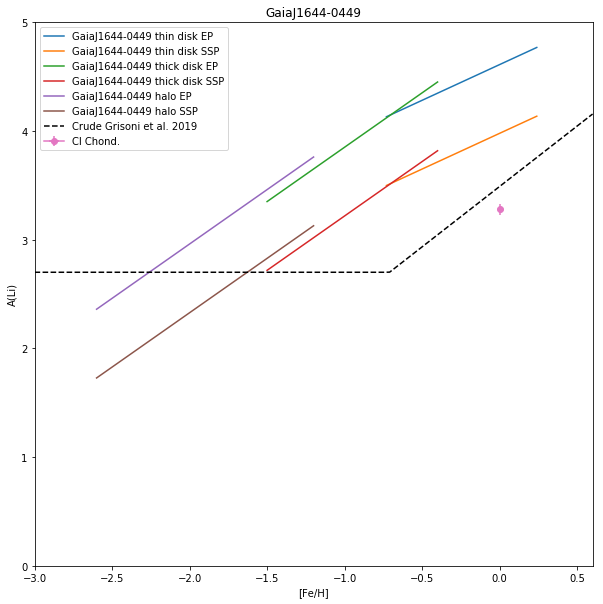

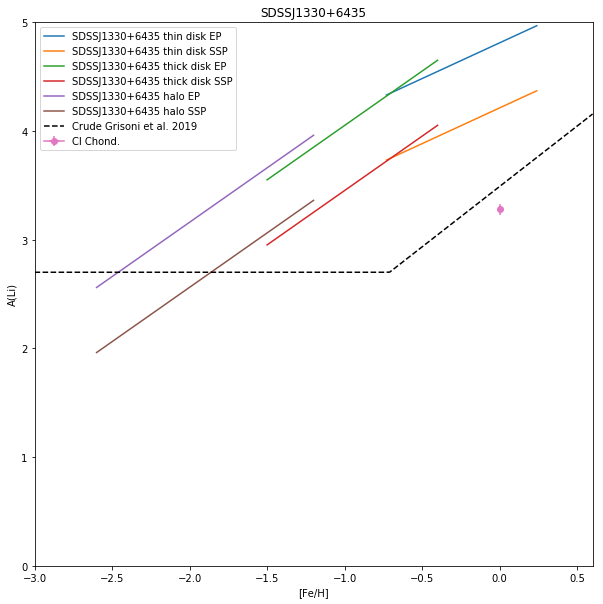

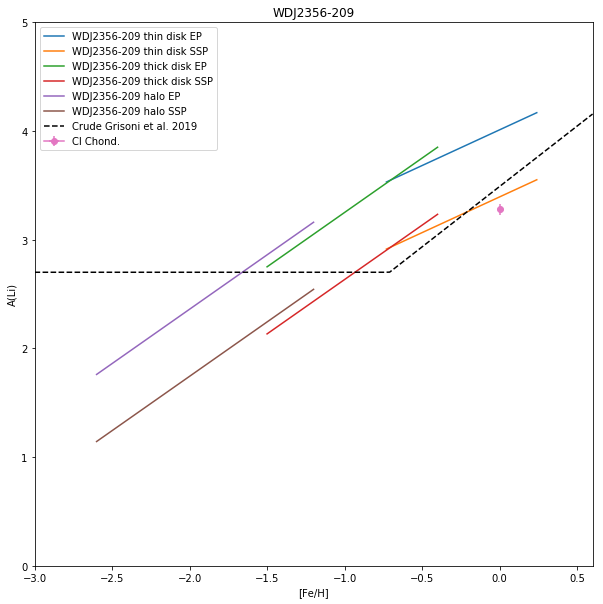

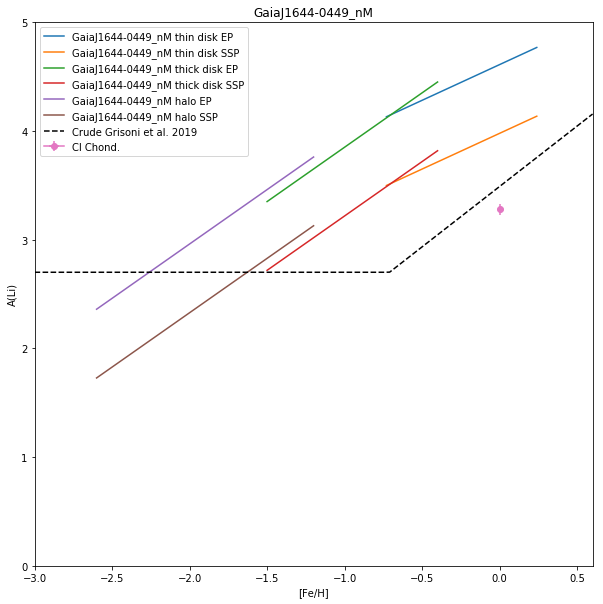

In [21]:
#row= wd_abund_table[np.where(wd_abund_table['name']=='GaiaJ1644-0449')]
for row in wd_abund_table:
    plt.figure(figsize=(10,10))
    plt.plot(FeH_thin, LiHe_to_ALi(row, CaFe_thin, FeH_thin, phase='EP'), label=row['name']+' thin disk EP')
    plt.plot(FeH_thin, LiHe_to_ALi(row, CaFe_thin, FeH_thin, phase='SSP'), label=row['name']+' thin disk SSP')
    plt.plot(FeH_thick, LiHe_to_ALi(row, CaFe_thick, FeH_thick, phase='EP'), label=row['name']+' thick disk EP')
    plt.plot(FeH_thick, LiHe_to_ALi(row, CaFe_thick, FeH_thick, phase='SSP'), label=row['name']+' thick disk SSP')
    plt.plot(FeH_halo, LiHe_to_ALi(row, CaFe_halo, FeH_halo, phase='EP'), label=row['name']+' halo EP')
    plt.plot(FeH_halo, LiHe_to_ALi(row, CaFe_halo, FeH_halo, phase='SSP'), label=row['name']+' halo SSP')
    plt.title(row['name'])
    make_plot()

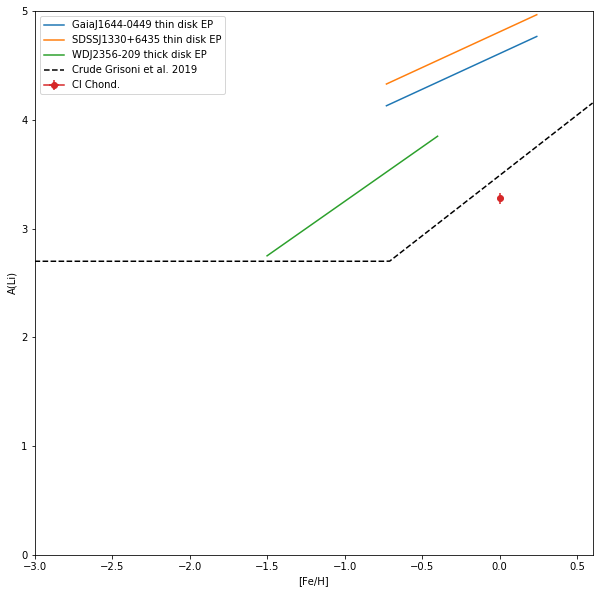

In [22]:
plt.figure(figsize=(10,10))
plt.plot(FeH_thin, LiHe_to_ALi(wd_abund_table.loc['GaiaJ1644-0449'], CaFe_thin, FeH_thin, phase='EP'), label=wd_abund_table.loc['GaiaJ1644-0449']['name']+' thin disk EP')
plt.plot(FeH_thin, LiHe_to_ALi(wd_abund_table.loc['SDSSJ1330+6435'], CaFe_thin, FeH_thin, phase='EP'), label=wd_abund_table.loc['SDSSJ1330+6435']['name']+' thin disk EP')
plt.plot(FeH_thick, LiHe_to_ALi(wd_abund_table.loc['WDJ2356-209'], CaFe_thick, FeH_thick, phase='EP'), label=wd_abund_table.loc['WDJ2356-209']['name']+' thick disk EP')
make_plot()

However, I really should put SDSSJ1330 into declining phase for our purposes since it's actually supposed to be chondritic log(Na/Ca) values, which I calculated over in LiCa_vs_NaCa.ipynb to be log(Li/Ca)=-1.889 to way to many sig figs.

In [23]:
j1330_LiCa_DP=-1.889

In [24]:
def get_DP_ALi(LiCa_DP):
    return LiCa_DP+(CaFe_thin+FeH_thin)+lodders_table.loc['Ca']['A_el']
j1330_ALi_vals= j1330_LiCa_DP+(CaFe_thin+FeH_thin)+lodders_table.loc['Ca']['A_el']
j1644_ALi_vals= get_DP_ALi(wd_abund_table.loc['GaiaJ1644-0449']['li/ca'])
j1330_achond_ALi=get_DP_ALi(-3.2019492067508324)
j1644_achond_ALi=get_DP_ALi(-3.0372458053042237)

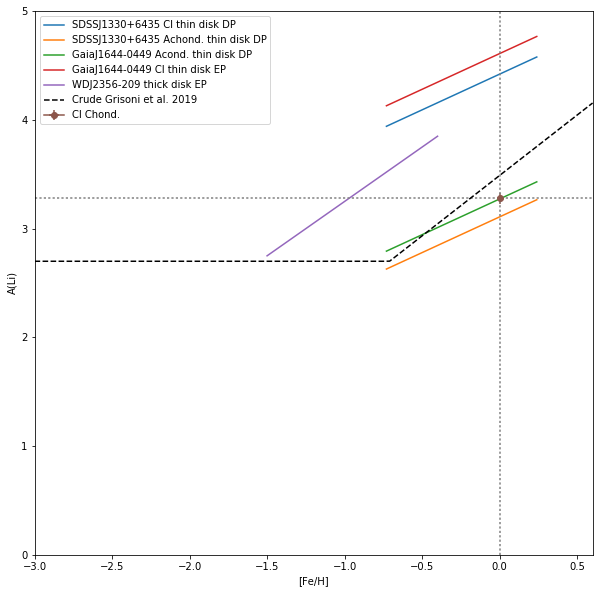

In [25]:
plt.figure(figsize=(10,10))
plt.plot(FeH_thin,j1330_ALi_vals , label=wd_abund_table.loc['SDSSJ1330+6435']['name']+' CI thin disk DP')
plt.plot(FeH_thin,j1330_achond_ALi , label=wd_abund_table.loc['SDSSJ1330+6435']['name']+' Achond. thin disk DP')
plt.plot(FeH_thin,j1644_achond_ALi , label=wd_abund_table.loc['GaiaJ1644-0449']['name']+' Acond. thin disk DP')



plt.plot(FeH_thin, LiHe_to_ALi(wd_abund_table.loc['GaiaJ1644-0449'], CaFe_thin, FeH_thin, phase='EP'), label=wd_abund_table.loc['GaiaJ1644-0449']['name']+' CI thin disk EP')
#plt.plot(FeH_thin, LiHe_to_ALi(wd_abund_table.loc['SDSSJ1330+6435'], CaFe_thin, FeH_thin, phase='EP'), label=wd_abund_table.loc['SDSSJ1330+6435']['name']+' thin disk EP')
plt.plot(FeH_thick, LiHe_to_ALi(wd_abund_table.loc['WDJ2356-209'], CaFe_thick, FeH_thick, phase='EP'), label=wd_abund_table.loc['WDJ2356-209']['name']+' thick disk EP')
plt.axvline(x=0,linestyle=':', color='grey')
plt.axhline(y=lodders_table.loc['Li']['A_el'],linestyle=':', color='grey')
make_plot()

In [26]:
def make_dist(value,sigma, npoints):
    return np.random.normal(loc=value, scale=sigma, size=npoints )



In [27]:
n_random=100000
#j1644_LiCa_dist=make_dist(wd_abund_table.loc['GaiaJ1644-0449']['li/ca'],wd_abund_table.loc['GaiaJ1644-0449']['li/ca_err'], n_random)
#j1330_LiCa_dist=make_dist(wd_abund_table.loc['SDSSJ1330+6435']['li/ca'],wd_abund_table.loc['SDSSJ1330+6435']['li/ca_err'], n_random)
#j1330_LiCa_dist=make_dist(j1330_LiCa_DP,wd_abund_table.loc['SDSSJ1330+6435']['li/ca_err'], n_random)

j1644_LiCa_dist=make_dist(wd_abund_table.loc['GaiaJ1644-0449']['dp_chond_li/ca'],wd_abund_table.loc['GaiaJ1644-0449']['dp_chond_li/ca_err'], n_random)
j1330_LiCa_dist=make_dist(wd_abund_table.loc['SDSSJ1330+6435']['dp_chond_li/ca'],wd_abund_table.loc['SDSSJ1330+6435']['dp_chond_li/ca_err'], n_random)

j1330_ALi_vals=wd_abund_table.loc['SDSSJ1330+6435']['dp_chond_li/ca']+(CaFe_thin+FeH_thin)+lodders_table.loc['Ca']['A_el']
j1644_ALi_vals= wd_abund_table.loc['GaiaJ1644-0449']['dp_chond_li/ca']+(CaFe_thin+FeH_thin)+lodders_table.loc['Ca']['A_el']



CaFe_dist=make_dist(get_CaFe_thin(FeH_thin[-1]), 0.1, n_random)
ACa_dist=make_dist(lodders_table.loc['Ca']['A_el'], lodders_table.loc['Ca']['A_el_err'],n_random)

-0.342857142857


In [28]:
j1644_ALi_dist=j1644_LiCa_dist+CaFe_dist+FeH_thin[-1]+ACa_dist
j1330_ALi_dist=j1330_LiCa_dist+CaFe_dist+FeH_thin[-1]+ACa_dist

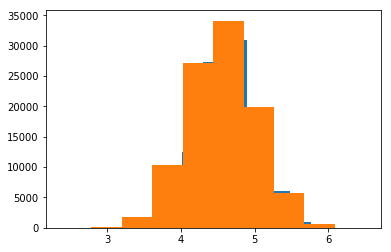

In [29]:
plt.hist(j1644_ALi_dist)
plt.hist(j1330_ALi_dist)
plt.show()

In [30]:
j1644_ALi_err= np.std(j1644_ALi_dist)
j1330_ALi_err= np.std(j1330_ALi_dist)
print(j1644_ALi_err, j1330_ALi_err)

0.355739804913 0.461546286569


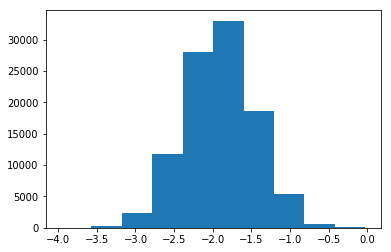

In [31]:
plt.hist(j1330_LiCa_dist)
plt.show()

In [32]:
np.sqrt(wd_abund_table.loc['GaiaJ1644-0449']['li/ca_err']**2+0.1**2+lodders_table.loc['Ca']['A_el_err']**2)

0.20688160865577201

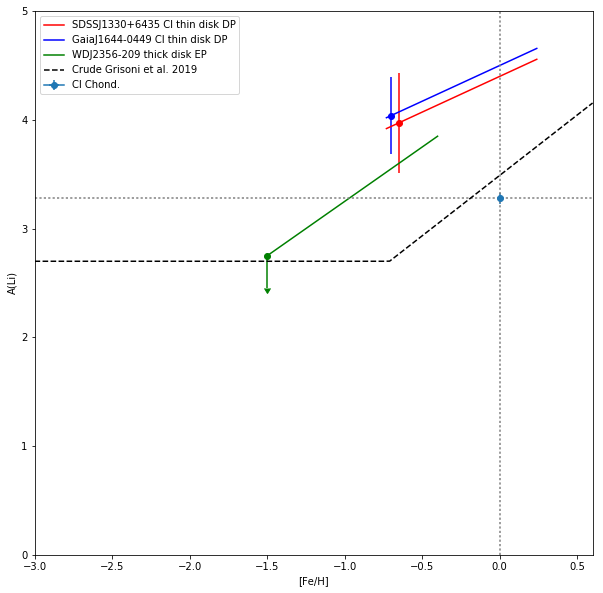

In [33]:
plt.figure(figsize=(10,10))
plt.plot(FeH_thin,j1330_ALi_vals , label=wd_abund_table.loc['SDSSJ1330+6435']['name']+' CI thin disk DP', color='r')
plt.errorbar(FeH_thin[8], j1330_ALi_vals[8], yerr=j1330_ALi_err, color='r',marker='o')


plt.plot(FeH_thin, j1644_ALi_vals, label=wd_abund_table.loc['GaiaJ1644-0449']['name']+' CI thin disk DP', color='b')
plt.errorbar(FeH_thin[3], j1644_ALi_vals[3], yerr=j1644_ALi_err, color='b', marker='o')



#plt.plot(FeH_thin, LiHe_to_ALi(wd_abund_table.loc['SDSSJ1330+6435'], CaFe_thin, FeH_thin, phase='EP'), label=wd_abund_table.loc['SDSSJ1330+6435']['name']+' thin disk EP')
plt.plot(FeH_thick, LiHe_to_ALi(wd_abund_table.loc['WDJ2356-209'], CaFe_thick, FeH_thick, phase='EP'), label=wd_abund_table.loc['WDJ2356-209']['name']+' thick disk EP', color='g')
plt.errorbar(FeH_thick[0], LiHe_to_ALi(wd_abund_table.loc['WDJ2356-209'], CaFe_thick, FeH_thick, phase='EP')[0],yerr=0.3, uplims=True, color='g', marker='o')
plt.axvline(x=0,linestyle=':', color='grey')
plt.axhline(y=lodders_table.loc['Li']['A_el'],linestyle=':', color='grey')
make_plot()

In [34]:
n_random=100000
#j1644_LiCa_dist=make_dist(wd_abund_table.loc['GaiaJ1644-0449']['li/ca'],wd_abund_table.loc['GaiaJ1644-0449']['li/ca_err'], n_random)
#j1330_LiCa_dist=make_dist(wd_abund_table.loc['SDSSJ1330+6435']['li/ca'],wd_abund_table.loc['SDSSJ1330+6435']['li/ca_err'], n_random)
#j1330_LiCa_dist=make_dist(j1330_LiCa_DP,wd_abund_table.loc['SDSSJ1330+6435']['li/ca_err'], n_random)

j1644_LiCa_dist=make_dist(wd_abund_table.loc['GaiaJ1644-0449']['dp_sioux_li/ca'],wd_abund_table.loc['GaiaJ1644-0449']['dp_sioux_li/ca_err'], n_random)
j1330_LiCa_dist=make_dist(wd_abund_table.loc['SDSSJ1330+6435']['dp_sioux_li/ca'],wd_abund_table.loc['SDSSJ1330+6435']['dp_sioux_li/ca_err'], n_random)


CaFe_dist=make_dist(get_CaFe_thin(FeH_thin[-1]), 0.1, n_random)
ACa_dist=make_dist(lodders_table.loc['Ca']['A_el'], lodders_table.loc['Ca']['A_el_err'],n_random)

chond_corr_achond= 0.12

j1330_ALi_vals=wd_abund_table.loc['SDSSJ1330+6435']['dp_sioux_li/ca']+(CaFe_thin+FeH_thin)+lodders_table.loc['Ca']['A_el']+chond_corr_achond
j1644_ALi_vals= wd_abund_table.loc['GaiaJ1644-0449']['dp_sioux_li/ca']+(CaFe_thin+FeH_thin)+lodders_table.loc['Ca']['A_el']+chond_corr_achond



j1644_ALi_dist=j1644_LiCa_dist+CaFe_dist+FeH_thin[-1]+ACa_dist
j1330_ALi_dist=j1330_LiCa_dist+CaFe_dist+FeH_thin[-1]+ACa_dist
j1644_ALi_err= np.std(j1644_ALi_dist)
j1330_ALi_err= np.std(j1330_ALi_dist)
print(j1644_ALi_err, j1330_ALi_err)

-0.342857142857
0.354730569518 0.509165391316


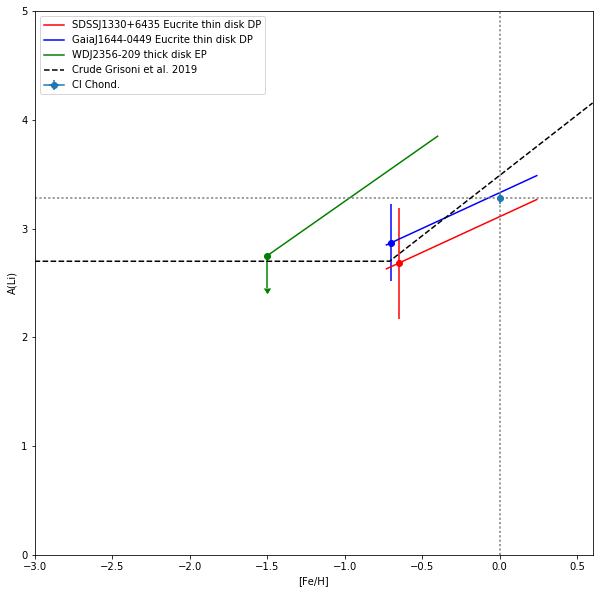

In [35]:
plt.figure(figsize=(10,10))
plt.plot(FeH_thin,j1330_ALi_vals , label=wd_abund_table.loc['SDSSJ1330+6435']['name']+' Eucrite thin disk DP', color='r')
plt.errorbar(FeH_thin[8], j1330_ALi_vals[8], yerr=j1330_ALi_err, color='r',marker='o')


plt.plot(FeH_thin, j1644_ALi_vals, label=wd_abund_table.loc['GaiaJ1644-0449']['name']+' Eucrite thin disk DP', color='b')
plt.errorbar(FeH_thin[3], j1644_ALi_vals[3], yerr=j1644_ALi_err, color='b', marker='o')



#plt.plot(FeH_thin, LiHe_to_ALi(wd_abund_table.loc['SDSSJ1330+6435'], CaFe_thin, FeH_thin, phase='EP'), label=wd_abund_table.loc['SDSSJ1330+6435']['name']+' thin disk EP')
plt.plot(FeH_thick, LiHe_to_ALi(wd_abund_table.loc['WDJ2356-209'], CaFe_thick, FeH_thick, phase='EP'), label=wd_abund_table.loc['WDJ2356-209']['name']+' thick disk EP', color='g')
plt.errorbar(FeH_thick[0], LiHe_to_ALi(wd_abund_table.loc['WDJ2356-209'], CaFe_thick, FeH_thick, phase='EP')[0],yerr=0.3, uplims=True, color='g', marker='o')
plt.axvline(x=0,linestyle=':', color='grey')
plt.axhline(y=lodders_table.loc['Li']['A_el'],linestyle=':', color='grey')
make_plot()

In [36]:
print(np.log10(5.2*10**(-10))+12)

2.71600334363


In [37]:
print(np.log10(4.15**(-10)))

-6.18048096712


In [38]:
print(np.log10(5.18*10**(-10))+12)

2.71432975975


In [39]:
print(np.log10(4.98*10**(-10))+12)

2.69722934276


In [40]:
print(lodders_table['A_el'][np.where(lodders_table['element']=='Ca')]-lodders_table['A_el'][np.where(lodders_table['element']=='Fe')])

 A_el
-----
-1.15


In [41]:
print(lodders_table['A_el'][np.where(lodders_table['element']=='Fe')])

A_el
----
7.46


In [42]:
print(lodders_table['A_el'][np.where(lodders_table['element']=='Ca')])

A_el
----
6.31


In [43]:
lodders_table.pprint()

element A_el A_el_err
------- ---- --------
     Li 3.28     0.05
     Na 6.29     0.04
     Ca 6.31     0.02
     Fe 7.46     0.08
     Mg 7.54     0.06


In [44]:
print(lodders_table['A_el'][np.where(lodders_table['element']=='Mg')]-lodders_table['A_el'][np.where(lodders_table['element']=='Fe')])

A_el
----
0.08


In [45]:
n_random=100000
#j1644_LiCa_dist=make_dist(wd_abund_table.loc['GaiaJ1644-0449']['li/ca'],wd_abund_table.loc['GaiaJ1644-0449']['li/ca_err'], n_random)
#j1330_LiCa_dist=make_dist(wd_abund_table.loc['SDSSJ1330+6435']['li/ca'],wd_abund_table.loc['SDSSJ1330+6435']['li/ca_err'], n_random)
#j1330_LiCa_dist=make_dist(j1330_LiCa_DP,wd_abund_table.loc['SDSSJ1330+6435']['li/ca_err'], n_random)

j1644_LiCa_dist=make_dist(wd_abund_table.loc['GaiaJ1644-0449']['dp_bulk_earth_li/ca'],wd_abund_table.loc['GaiaJ1644-0449']['dp_bulk_earth_li/ca_err'], n_random)
j1330_LiCa_dist=make_dist(wd_abund_table.loc['SDSSJ1330+6435']['dp_bulk_earth_li/ca'],wd_abund_table.loc['SDSSJ1330+6435']['dp_bulk_earth_li/ca_err'], n_random)


CaFe_dist=make_dist(get_CaFe_thin(FeH_thin[-1]), 0.1, n_random)
ACa_dist=make_dist(lodders_table.loc['Ca']['A_el'], lodders_table.loc['Ca']['A_el_err'],n_random)

chond_corr_achond=0.23

j1330_ALi_vals=wd_abund_table.loc['SDSSJ1330+6435']['dp_bulk_earth_li/ca']+(CaFe_thin+FeH_thin)+lodders_table.loc['Ca']['A_el']+chond_corr_achond
j1644_ALi_vals= wd_abund_table.loc['GaiaJ1644-0449']['dp_bulk_earth_li/ca']+(CaFe_thin+FeH_thin)+lodders_table.loc['Ca']['A_el']+chond_corr_achond



j1644_ALi_dist=j1644_LiCa_dist+CaFe_dist+FeH_thin[-1]+ACa_dist
j1330_ALi_dist=j1330_LiCa_dist+CaFe_dist+FeH_thin[-1]+ACa_dist
j1644_ALi_err= np.std(j1644_ALi_dist)
j1330_ALi_err= np.std(j1330_ALi_dist)
print(j1644_ALi_err, j1330_ALi_err)

-0.342857142857
0.354640235244 0.479582180642


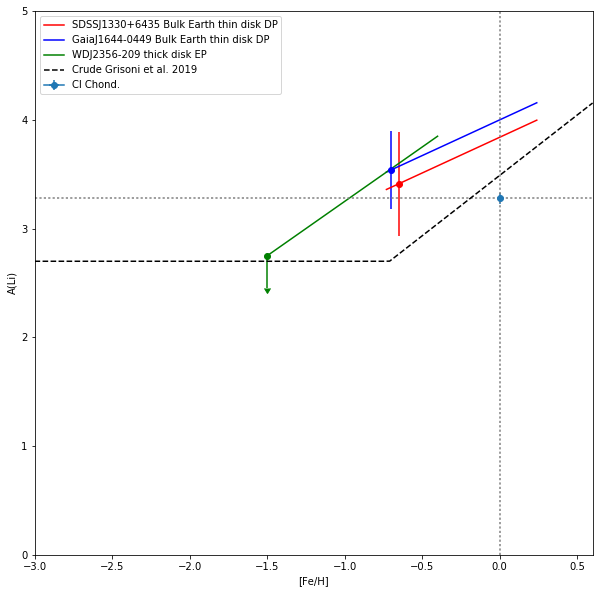

In [46]:
plt.figure(figsize=(10,10))
plt.plot(FeH_thin,j1330_ALi_vals , label=wd_abund_table.loc['SDSSJ1330+6435']['name']+' Bulk Earth thin disk DP', color='r')
plt.errorbar(FeH_thin[8], j1330_ALi_vals[8], yerr=j1330_ALi_err, color='r',marker='o')


plt.plot(FeH_thin, j1644_ALi_vals, label=wd_abund_table.loc['GaiaJ1644-0449']['name']+' Bulk Earth thin disk DP', color='b')
plt.errorbar(FeH_thin[3], j1644_ALi_vals[3], yerr=j1644_ALi_err, color='b', marker='o')


#plt.plot(FeH_thin, LiHe_to_ALi(wd_abund_table.loc['SDSSJ1330+6435'], CaFe_thin, FeH_thin, phase='EP'), label=wd_abund_table.loc['SDSSJ1330+6435']['name']+' thin disk EP')
plt.plot(FeH_thick, LiHe_to_ALi(wd_abund_table.loc['WDJ2356-209'], CaFe_thick, FeH_thick, phase='EP'), label=wd_abund_table.loc['WDJ2356-209']['name']+' thick disk EP', color='g')
plt.errorbar(FeH_thick[0], LiHe_to_ALi(wd_abund_table.loc['WDJ2356-209'], CaFe_thick, FeH_thick, phase='EP')[0],yerr=0.3, uplims=True, color='g', marker='o')
plt.axvline(x=0,linestyle=':', color='grey')
plt.axhline(y=lodders_table.loc['Li']['A_el'],linestyle=':', color='grey')
make_plot()

In [47]:
#Earth Crust
n_random=100000
#j1644_LiCa_dist=make_dist(wd_abund_table.loc['GaiaJ1644-0449']['li/ca'],wd_abund_table.loc['GaiaJ1644-0449']['li/ca_err'], n_random)
#j1330_LiCa_dist=make_dist(wd_abund_table.loc['SDSSJ1330+6435']['li/ca'],wd_abund_table.loc['SDSSJ1330+6435']['li/ca_err'], n_random)
#j1330_LiCa_dist=make_dist(j1330_LiCa_DP,wd_abund_table.loc['SDSSJ1330+6435']['li/ca_err'], n_random)

j1644_LiCa_dist=make_dist(wd_abund_table.loc['GaiaJ1644-0449']['dp_crust_li/ca'],wd_abund_table.loc['GaiaJ1644-0449']['dp_crust_li/ca_err'], n_random)
j1330_LiCa_dist=make_dist(wd_abund_table.loc['SDSSJ1330+6435']['dp_crust_li/ca'],wd_abund_table.loc['SDSSJ1330+6435']['dp_crust_li/ca_err'], n_random)


CaFe_dist=make_dist(get_CaFe_thin(FeH_thin[-1]), 0.1, n_random)
ACa_dist=make_dist(lodders_table.loc['Ca']['A_el'], lodders_table.loc['Ca']['A_el_err'],n_random)

chond_corr_achond=-0.47

j1330_ALi_vals=wd_abund_table.loc['SDSSJ1330+6435']['dp_crust_li/ca']+(CaFe_thin+FeH_thin)+lodders_table.loc['Ca']['A_el']+chond_corr_achond
j1644_ALi_vals= wd_abund_table.loc['GaiaJ1644-0449']['dp_crust_li/ca']+(CaFe_thin+FeH_thin)+lodders_table.loc['Ca']['A_el']+chond_corr_achond



j1644_ALi_dist=j1644_LiCa_dist+CaFe_dist+FeH_thin[-1]+ACa_dist
j1330_ALi_dist=j1330_LiCa_dist+CaFe_dist+FeH_thin[-1]+ACa_dist
j1644_ALi_err= np.std(j1644_ALi_dist)
j1330_ALi_err= np.std(j1330_ALi_dist)
print(j1644_ALi_err, j1330_ALi_err)

-0.342857142857
0.356095939516 0.480597552366


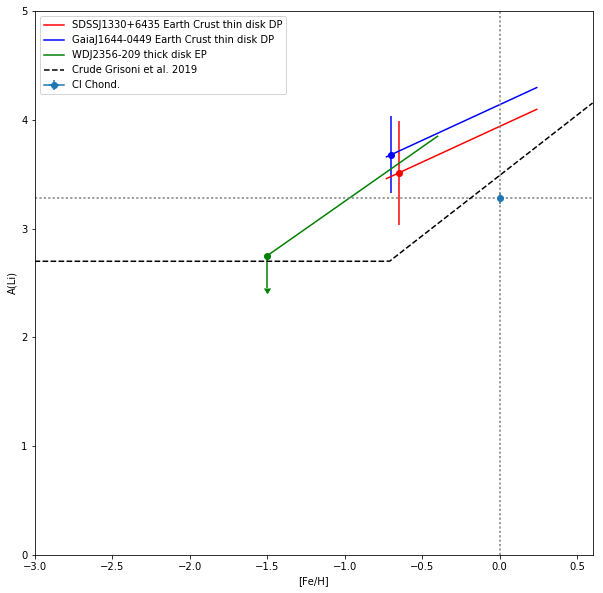

In [48]:
plt.figure(figsize=(10,10))
plt.plot(FeH_thin,j1330_ALi_vals , label=wd_abund_table.loc['SDSSJ1330+6435']['name']+' Earth Crust thin disk DP', color='r')
plt.errorbar(FeH_thin[8], j1330_ALi_vals[8], yerr=j1330_ALi_err, color='r',marker='o')


plt.plot(FeH_thin, j1644_ALi_vals, label=wd_abund_table.loc['GaiaJ1644-0449']['name']+' Earth Crust thin disk DP', color='b')
plt.errorbar(FeH_thin[3], j1644_ALi_vals[3], yerr=j1644_ALi_err, color='b', marker='o')


#plt.plot(FeH_thin, LiHe_to_ALi(wd_abund_table.loc['SDSSJ1330+6435'], CaFe_thin, FeH_thin, phase='EP'), label=wd_abund_table.loc['SDSSJ1330+6435']['name']+' thin disk EP')
plt.plot(FeH_thick, LiHe_to_ALi(wd_abund_table.loc['WDJ2356-209'], CaFe_thick, FeH_thick, phase='EP'), label=wd_abund_table.loc['WDJ2356-209']['name']+' thick disk EP', color='g')
plt.errorbar(FeH_thick[0], LiHe_to_ALi(wd_abund_table.loc['WDJ2356-209'], CaFe_thick, FeH_thick, phase='EP')[0],yerr=0.3, uplims=True, color='g', marker='o')
plt.axvline(x=0,linestyle=':', color='grey')
plt.axhline(y=lodders_table.loc['Li']['A_el'],linestyle=':', color='grey')
make_plot()

### Angra Dos Reis Achondrite (below)

In [49]:
n_random=100000
#j1644_LiCa_dist=make_dist(wd_abund_table.loc['GaiaJ1644-0449']['li/ca'],wd_abund_table.loc['GaiaJ1644-0449']['li/ca_err'], n_random)
#j1330_LiCa_dist=make_dist(wd_abund_table.loc['SDSSJ1330+6435']['li/ca'],wd_abund_table.loc['SDSSJ1330+6435']['li/ca_err'], n_random)
#j1330_LiCa_dist=make_dist(j1330_LiCa_DP,wd_abund_table.loc['SDSSJ1330+6435']['li/ca_err'], n_random)

j1644_LiCa_dist=make_dist(wd_abund_table.loc['GaiaJ1644-0449']['dp_angra_li/ca'],wd_abund_table.loc['GaiaJ1644-0449']['dp_angra_li/ca_err'], n_random)
j1330_LiCa_dist=make_dist(wd_abund_table.loc['SDSSJ1330+6435']['dp_angra_li/ca'],wd_abund_table.loc['SDSSJ1330+6435']['dp_angra_li/ca_err'], n_random)


CaFe_dist=make_dist(get_CaFe_thin(FeH_thin[-1]), 0.1, n_random)
ACa_dist=make_dist(lodders_table.loc['Ca']['A_el'], lodders_table.loc['Ca']['A_el_err'],n_random)

chond_corr_achond=1.12

j1330_ALi_vals=wd_abund_table.loc['SDSSJ1330+6435']['dp_angra_li/ca']+(CaFe_thin+FeH_thin)+lodders_table.loc['Ca']['A_el']+chond_corr_achond
j1644_ALi_vals= wd_abund_table.loc['GaiaJ1644-0449']['dp_angra_li/ca']+(CaFe_thin+FeH_thin)+lodders_table.loc['Ca']['A_el']+chond_corr_achond



j1644_ALi_dist=j1644_LiCa_dist+CaFe_dist+FeH_thin[-1]+ACa_dist
j1330_ALi_dist=j1330_LiCa_dist+CaFe_dist+FeH_thin[-1]+ACa_dist
j1644_ALi_err= np.std(j1644_ALi_dist)
j1330_ALi_err= np.std(j1330_ALi_dist)
print(j1644_ALi_err, j1330_ALi_err)

-0.342857142857
0.42236287046 0.510782732295


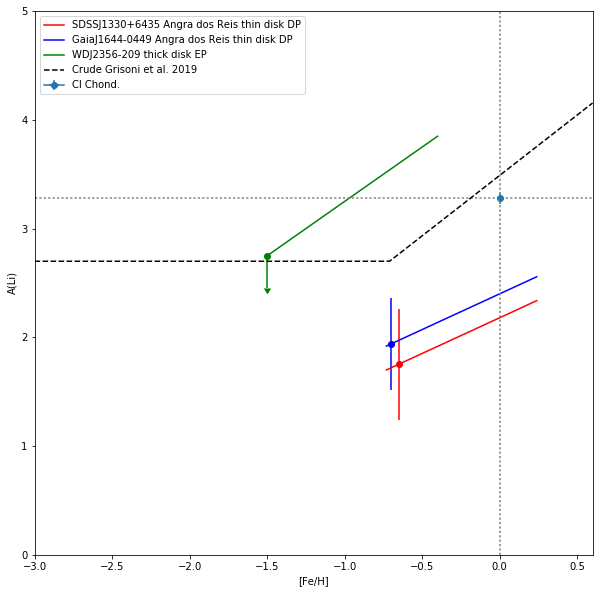

In [50]:
plt.figure(figsize=(10,10))
plt.plot(FeH_thin,j1330_ALi_vals , label=wd_abund_table.loc['SDSSJ1330+6435']['name']+' Angra dos Reis thin disk DP', color='r')
plt.errorbar(FeH_thin[8], j1330_ALi_vals[8], yerr=j1330_ALi_err, color='r',marker='o')


plt.plot(FeH_thin, j1644_ALi_vals, label=wd_abund_table.loc['GaiaJ1644-0449']['name']+' Angra dos Reis thin disk DP', color='b')
plt.errorbar(FeH_thin[3], j1644_ALi_vals[3], yerr=j1644_ALi_err, color='b', marker='o')


#plt.plot(FeH_thin, LiHe_to_ALi(wd_abund_table.loc['SDSSJ1330+6435'], CaFe_thin, FeH_thin, phase='EP'), label=wd_abund_table.loc['SDSSJ1330+6435']['name']+' thin disk EP')
plt.plot(FeH_thick, LiHe_to_ALi(wd_abund_table.loc['WDJ2356-209'], CaFe_thick, FeH_thick, phase='EP'), label=wd_abund_table.loc['WDJ2356-209']['name']+' thick disk EP', color='g')
plt.errorbar(FeH_thick[0], LiHe_to_ALi(wd_abund_table.loc['WDJ2356-209'], CaFe_thick, FeH_thick, phase='EP')[0],yerr=0.3, uplims=True, color='g', marker='o')
plt.axvline(x=0,linestyle=':', color='grey')
plt.axhline(y=lodders_table.loc['Li']['A_el'],linestyle=':', color='grey')
make_plot()

# Bulk Mars Below

In [51]:
n_random=100000
#j1644_LiCa_dist=make_dist(wd_abund_table.loc['GaiaJ1644-0449']['li/ca'],wd_abund_table.loc['GaiaJ1644-0449']['li/ca_err'], n_random)
#j1330_LiCa_dist=make_dist(wd_abund_table.loc['SDSSJ1330+6435']['li/ca'],wd_abund_table.loc['SDSSJ1330+6435']['li/ca_err'], n_random)
#j1330_LiCa_dist=make_dist(j1330_LiCa_DP,wd_abund_table.loc['SDSSJ1330+6435']['li/ca_err'], n_random)

j1644_LiCa_dist=make_dist(wd_abund_table.loc['GaiaJ1644-0449']['dp_bulk_mars_li/ca'],wd_abund_table.loc['GaiaJ1644-0449']['dp_bulk_mars_li/ca_err'], n_random)
j1330_LiCa_dist=make_dist(wd_abund_table.loc['SDSSJ1330+6435']['dp_bulk_mars_li/ca'],wd_abund_table.loc['SDSSJ1330+6435']['dp_bulk_mars_li/ca_err'], n_random)


CaFe_dist=make_dist(get_CaFe_thin(FeH_thin[-1]), 0.1, n_random)
ACa_dist=make_dist(lodders_table.loc['Ca']['A_el'], lodders_table.loc['Ca']['A_el_err'],n_random)

chond_corr_achond=-0.03

j1330_ALi_vals=wd_abund_table.loc['SDSSJ1330+6435']['dp_bulk_mars_li/ca']+(CaFe_thin+FeH_thin)+lodders_table.loc['Ca']['A_el']+chond_corr_achond
j1644_ALi_vals= wd_abund_table.loc['GaiaJ1644-0449']['dp_bulk_mars_li/ca']+(CaFe_thin+FeH_thin)+lodders_table.loc['Ca']['A_el']+chond_corr_achond



j1644_ALi_dist=j1644_LiCa_dist+CaFe_dist+FeH_thin[-1]+ACa_dist
j1330_ALi_dist=j1330_LiCa_dist+CaFe_dist+FeH_thin[-1]+ACa_dist
j1644_ALi_err= np.std(j1644_ALi_dist)
j1330_ALi_err= np.std(j1330_ALi_dist)
print(j1644_ALi_err, j1330_ALi_err)

-0.342857142857
0.356260104395 0.54848812408


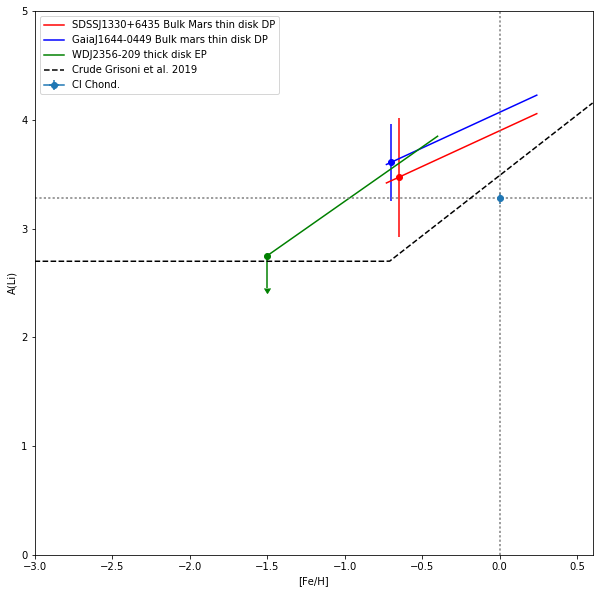

In [52]:
plt.figure(figsize=(10,10))
plt.plot(FeH_thin,j1330_ALi_vals , label=wd_abund_table.loc['SDSSJ1330+6435']['name']+' Bulk Mars thin disk DP', color='r')
plt.errorbar(FeH_thin[8], j1330_ALi_vals[8], yerr=j1330_ALi_err, color='r',marker='o')


plt.plot(FeH_thin, j1644_ALi_vals, label=wd_abund_table.loc['GaiaJ1644-0449']['name']+' Bulk mars thin disk DP', color='b')
plt.errorbar(FeH_thin[3], j1644_ALi_vals[3], yerr=j1644_ALi_err, color='b', marker='o')


#plt.plot(FeH_thin, LiHe_to_ALi(wd_abund_table.loc['SDSSJ1330+6435'], CaFe_thin, FeH_thin, phase='EP'), label=wd_abund_table.loc['SDSSJ1330+6435']['name']+' thin disk EP')
plt.plot(FeH_thick, LiHe_to_ALi(wd_abund_table.loc['WDJ2356-209'], CaFe_thick, FeH_thick, phase='EP'), label=wd_abund_table.loc['WDJ2356-209']['name']+' thick disk EP', color='g')
plt.errorbar(FeH_thick[0], LiHe_to_ALi(wd_abund_table.loc['WDJ2356-209'], CaFe_thick, FeH_thick, phase='EP')[0],yerr=0.3, uplims=True, color='g', marker='o')
plt.axvline(x=0,linestyle=':', color='grey')
plt.axhline(y=lodders_table.loc['Li']['A_el'],linestyle=':', color='grey')
make_plot()

-0.342857142857
0.346175465839 0.470907576787


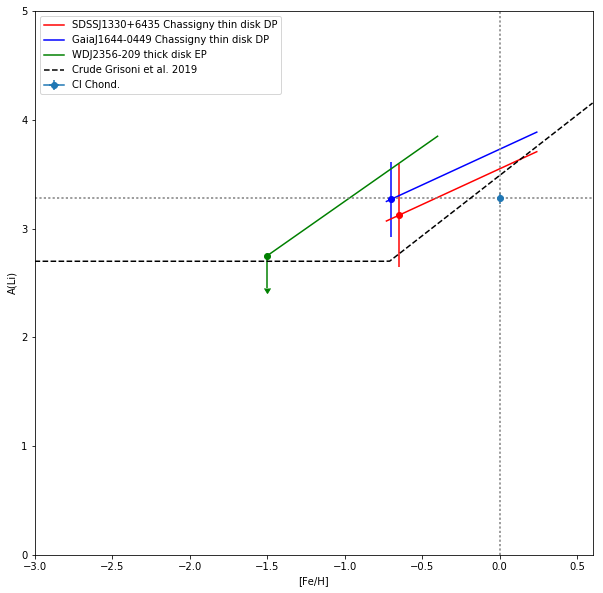

In [53]:
n_random=100000
#j1644_LiCa_dist=make_dist(wd_abund_table.loc['GaiaJ1644-0449']['li/ca'],wd_abund_table.loc['GaiaJ1644-0449']['li/ca_err'], n_random)
#j1330_LiCa_dist=make_dist(wd_abund_table.loc['SDSSJ1330+6435']['li/ca'],wd_abund_table.loc['SDSSJ1330+6435']['li/ca_err'], n_random)
#j1330_LiCa_dist=make_dist(j1330_LiCa_DP,wd_abund_table.loc['SDSSJ1330+6435']['li/ca_err'], n_random)

j1644_LiCa_dist=make_dist(wd_abund_table.loc['GaiaJ1644-0449']['dp_chassigny_li/ca'],wd_abund_table.loc['GaiaJ1644-0449']['dp_chassigny_li/ca_err'], n_random)
j1330_LiCa_dist=make_dist(wd_abund_table.loc['SDSSJ1330+6435']['dp_chassigny_li/ca'],wd_abund_table.loc['SDSSJ1330+6435']['dp_chassigny_li/ca_err'], n_random)


CaFe_dist=make_dist(get_CaFe_thin(FeH_thin[-1]), 0.1, n_random)
ACa_dist=make_dist(lodders_table.loc['Ca']['A_el'], lodders_table.loc['Ca']['A_el_err'],n_random)

chond_corr_achond=-0.26

j1330_ALi_vals=wd_abund_table.loc['SDSSJ1330+6435']['dp_chassigny_li/ca']+(CaFe_thin+FeH_thin)+lodders_table.loc['Ca']['A_el']+chond_corr_achond
j1644_ALi_vals= wd_abund_table.loc['GaiaJ1644-0449']['dp_chassigny_li/ca']+(CaFe_thin+FeH_thin)+lodders_table.loc['Ca']['A_el']+chond_corr_achond



j1644_ALi_dist=j1644_LiCa_dist+CaFe_dist+FeH_thin[-1]+ACa_dist
j1330_ALi_dist=j1330_LiCa_dist+CaFe_dist+FeH_thin[-1]+ACa_dist
j1644_ALi_err= np.std(j1644_ALi_dist)
j1330_ALi_err= np.std(j1330_ALi_dist)
print(j1644_ALi_err, j1330_ALi_err)

plt.figure(figsize=(10,10))
plt.plot(FeH_thin,j1330_ALi_vals , label=wd_abund_table.loc['SDSSJ1330+6435']['name']+' Chassigny thin disk DP', color='r')
plt.errorbar(FeH_thin[8], j1330_ALi_vals[8], yerr=j1330_ALi_err, color='r',marker='o')


plt.plot(FeH_thin, j1644_ALi_vals, label=wd_abund_table.loc['GaiaJ1644-0449']['name']+' Chassigny thin disk DP', color='b')
plt.errorbar(FeH_thin[3], j1644_ALi_vals[3], yerr=j1644_ALi_err, color='b', marker='o')


#plt.plot(FeH_thin, LiHe_to_ALi(wd_abund_table.loc['SDSSJ1330+6435'], CaFe_thin, FeH_thin, phase='EP'), label=wd_abund_table.loc['SDSSJ1330+6435']['name']+' thin disk EP')
plt.plot(FeH_thick, LiHe_to_ALi(wd_abund_table.loc['WDJ2356-209'], CaFe_thick, FeH_thick, phase='EP'), label=wd_abund_table.loc['WDJ2356-209']['name']+' thick disk EP', color='g')
plt.errorbar(FeH_thick[0], LiHe_to_ALi(wd_abund_table.loc['WDJ2356-209'], CaFe_thick, FeH_thick, phase='EP')[0],yerr=0.3, uplims=True, color='g', marker='o')
plt.axvline(x=0,linestyle=':', color='grey')
plt.axhline(y=lodders_table.loc['Li']['A_el'],linestyle=':', color='grey')
make_plot()

-0.342857142857
0.374930319347 0.500494555664


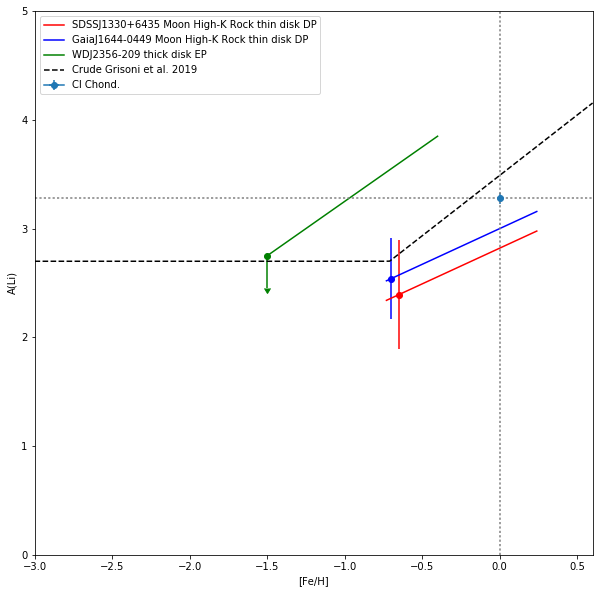

In [54]:
n_random=100000
#j1644_LiCa_dist=make_dist(wd_abund_table.loc['GaiaJ1644-0449']['li/ca'],wd_abund_table.loc['GaiaJ1644-0449']['li/ca_err'], n_random)
#j1330_LiCa_dist=make_dist(wd_abund_table.loc['SDSSJ1330+6435']['li/ca'],wd_abund_table.loc['SDSSJ1330+6435']['li/ca_err'], n_random)
#j1330_LiCa_dist=make_dist(j1330_LiCa_DP,wd_abund_table.loc['SDSSJ1330+6435']['li/ca_err'], n_random)

j1644_LiCa_dist=make_dist(wd_abund_table.loc['GaiaJ1644-0449']['dp_highk_moon_li/ca'],wd_abund_table.loc['GaiaJ1644-0449']['dp_highk_moon_li/ca_err'], n_random)
j1330_LiCa_dist=make_dist(wd_abund_table.loc['SDSSJ1330+6435']['dp_highk_moon_li/ca'],wd_abund_table.loc['SDSSJ1330+6435']['dp_highk_moon_li/ca_err'], n_random)


CaFe_dist=make_dist(get_CaFe_thin(FeH_thin[-1]), 0.1, n_random)
ACa_dist=make_dist(lodders_table.loc['Ca']['A_el'], lodders_table.loc['Ca']['A_el_err'],n_random)

chond_corr_achond=-0.18

j1330_ALi_vals=wd_abund_table.loc['SDSSJ1330+6435']['dp_highk_moon_li/ca']+(CaFe_thin+FeH_thin)+lodders_table.loc['Ca']['A_el']+chond_corr_achond
j1644_ALi_vals= wd_abund_table.loc['GaiaJ1644-0449']['dp_highk_moon_li/ca']+(CaFe_thin+FeH_thin)+lodders_table.loc['Ca']['A_el']+chond_corr_achond



j1644_ALi_dist=j1644_LiCa_dist+CaFe_dist+FeH_thin[-1]+ACa_dist
j1330_ALi_dist=j1330_LiCa_dist+CaFe_dist+FeH_thin[-1]+ACa_dist
j1644_ALi_err= np.std(j1644_ALi_dist)
j1330_ALi_err= np.std(j1330_ALi_dist)
print(j1644_ALi_err, j1330_ALi_err)

plt.figure(figsize=(10,10))
plt.plot(FeH_thin,j1330_ALi_vals , label=wd_abund_table.loc['SDSSJ1330+6435']['name']+' Moon High-K Rock thin disk DP', color='r')
plt.errorbar(FeH_thin[8], j1330_ALi_vals[8], yerr=j1330_ALi_err, color='r',marker='o')


plt.plot(FeH_thin, j1644_ALi_vals, label=wd_abund_table.loc['GaiaJ1644-0449']['name']+' Moon High-K Rock thin disk DP', color='b')
plt.errorbar(FeH_thin[3], j1644_ALi_vals[3], yerr=j1644_ALi_err, color='b', marker='o')


#plt.plot(FeH_thin, LiHe_to_ALi(wd_abund_table.loc['SDSSJ1330+6435'], CaFe_thin, FeH_thin, phase='EP'), label=wd_abund_table.loc['SDSSJ1330+6435']['name']+' thin disk EP')
plt.plot(FeH_thick, LiHe_to_ALi(wd_abund_table.loc['WDJ2356-209'], CaFe_thick, FeH_thick, phase='EP'), label=wd_abund_table.loc['WDJ2356-209']['name']+' thick disk EP', color='g')
plt.errorbar(FeH_thick[0], LiHe_to_ALi(wd_abund_table.loc['WDJ2356-209'], CaFe_thick, FeH_thick, phase='EP')[0],yerr=0.3, uplims=True, color='g', marker='o')
plt.axvline(x=0,linestyle=':', color='grey')
plt.axhline(y=lodders_table.loc['Li']['A_el'],linestyle=':', color='grey')
make_plot()

# 2020-03-02 We're back to thinking that we caught all of these in early phase, but I've become less sure about J1644 and J1330 being in thick or thin disk. (J2356 is definitely not thin disk).

-0.342857142857
0.217365710922 0.366589438624
0.202950272659 0.358118895013


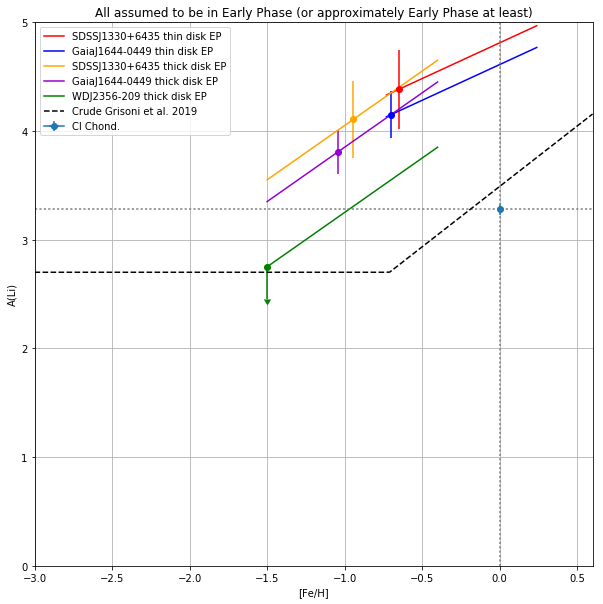

In [55]:
n_random=1000
#j1644_LiCa_dist=make_dist(wd_abund_table.loc['GaiaJ1644-0449']['li/ca'],wd_abund_table.loc['GaiaJ1644-0449']['li/ca_err'], n_random)
#j1330_LiCa_dist=make_dist(wd_abund_table.loc['SDSSJ1330+6435']['li/ca'],wd_abund_table.loc['SDSSJ1330+6435']['li/ca_err'], n_random)
#j1330_LiCa_dist=make_dist(j1330_LiCa_DP,wd_abund_table.loc['SDSSJ1330+6435']['li/ca_err'], n_random)

j1644_LiCa_dist=make_dist(wd_abund_table.loc['GaiaJ1644-0449']['li/ca'],wd_abund_table.loc['GaiaJ1644-0449']['li/ca_err'], n_random)
j1330_LiCa_dist=make_dist(wd_abund_table.loc['SDSSJ1330+6435']['li/ca'],wd_abund_table.loc['SDSSJ1330+6435']['li/ca_err'], n_random)


CaFe_dist=make_dist(get_CaFe_thin(FeH_thin[-1]), 0.1, n_random)
ACa_dist=make_dist(lodders_table.loc['Ca']['A_el'], lodders_table.loc['Ca']['A_el_err'],n_random)


j1330_ALi_vals=wd_abund_table.loc['SDSSJ1330+6435']['li/ca']+(CaFe_thin+FeH_thin)+lodders_table.loc['Ca']['A_el']
j1644_ALi_vals= wd_abund_table.loc['GaiaJ1644-0449']['li/ca']+(CaFe_thin+FeH_thin)+lodders_table.loc['Ca']['A_el']



j1644_ALi_dist=j1644_LiCa_dist+CaFe_dist+FeH_thin[-1]+ACa_dist
j1330_ALi_dist=j1330_LiCa_dist+CaFe_dist+FeH_thin[-1]+ACa_dist
j1644_ALi_err= np.std(j1644_ALi_dist)
j1330_ALi_err= np.std(j1330_ALi_dist)
print(j1644_ALi_err, j1330_ALi_err)

plt.figure(figsize=(10,10))
plt.plot(FeH_thin,j1330_ALi_vals , label=wd_abund_table.loc['SDSSJ1330+6435']['name']+' thin disk EP', color='r')
plt.errorbar(FeH_thin[8], j1330_ALi_vals[8], yerr=j1330_ALi_err, color='r',marker='o')


plt.plot(FeH_thin, j1644_ALi_vals, label=wd_abund_table.loc['GaiaJ1644-0449']['name']+' thin disk EP', color='b')
plt.errorbar(FeH_thin[3], j1644_ALi_vals[3], yerr=j1644_ALi_err, color='b', marker='o')

###########

CaFe_dist=make_dist(CaFe_thick, CaFe_thick_err, n_random)
ACa_dist=make_dist(lodders_table.loc['Ca']['A_el'], lodders_table.loc['Ca']['A_el_err'],n_random)


j1330_ALi_vals=wd_abund_table.loc['SDSSJ1330+6435']['li/ca']+(CaFe_thick+FeH_thick)+lodders_table.loc['Ca']['A_el']
j1644_ALi_vals= wd_abund_table.loc['GaiaJ1644-0449']['li/ca']+(CaFe_thick+FeH_thick)+lodders_table.loc['Ca']['A_el']



j1644_ALi_dist=j1644_LiCa_dist+CaFe_dist+FeH_thick[-1]+ACa_dist
j1330_ALi_dist=j1330_LiCa_dist+CaFe_dist+FeH_thick[-1]+ACa_dist
j1644_ALi_err= np.std(j1644_ALi_dist)
j1330_ALi_err= np.std(j1330_ALi_dist)
print(j1644_ALi_err, j1330_ALi_err)

plt.plot(FeH_thick,j1330_ALi_vals , label=wd_abund_table.loc['SDSSJ1330+6435']['name']+' thick disk EP', color='orange')
plt.errorbar(FeH_thick[-50], j1330_ALi_vals[-50], yerr=j1330_ALi_err, color='orange',marker='o')


plt.plot(FeH_thick, j1644_ALi_vals, label=wd_abund_table.loc['GaiaJ1644-0449']['name']+' thick disk EP', color='darkviolet')
plt.errorbar(FeH_thick[-59], j1644_ALi_vals[-59], yerr=j1644_ALi_err, color='darkviolet', marker='o')

############


#plt.plot(FeH_thin, LiHe_to_ALi(wd_abund_table.loc['SDSSJ1330+6435'], CaFe_thin, FeH_thin, phase='EP'), label=wd_abund_table.loc['SDSSJ1330+6435']['name']+' thin disk EP')
plt.plot(FeH_thick, LiHe_to_ALi(wd_abund_table.loc['WDJ2356-209'], CaFe_thick, FeH_thick, phase='EP'), label=wd_abund_table.loc['WDJ2356-209']['name']+' thick disk EP', color='g')
plt.errorbar(FeH_thick[0], LiHe_to_ALi(wd_abund_table.loc['WDJ2356-209'], CaFe_thick, FeH_thick, phase='EP')[0],yerr=0.3, uplims=True, color='g', marker='o')
plt.axvline(x=0,linestyle=':', color='grey')
plt.axhline(y=lodders_table.loc['Li']['A_el'],linestyle=':', color='grey')
plt.title('All assumed to be in Early Phase (or approximately Early Phase at least)')
plt.grid(True)
make_plot()

-0.342857142857
0.210900757774 0.368748941157
B_ALi
-----
 0.03
  0.1
 0.06
 0.06
 0.05
 0.06
 0.05
   --
 0.04
 0.05
  ...
 0.06
 0.04
   --
 0.04
 0.06
   --
 0.04
 0.09
   --
   --
 0.06
Length = 714 rows
<class 'astropy.table.column.MaskedColumn'>
<class 'astropy.table.column.MaskedColumn'>
ALi.shape (714,)


/Users/BenKaiser/.virtualenvs/stars/lib/python2.7/site-packages/numpy/core/numeric.py:531: UserWarning: Warning: converting a masked element to nan.
  return array(a, dtype, copy=False, order=order)


0.198974093683 0.365852585824


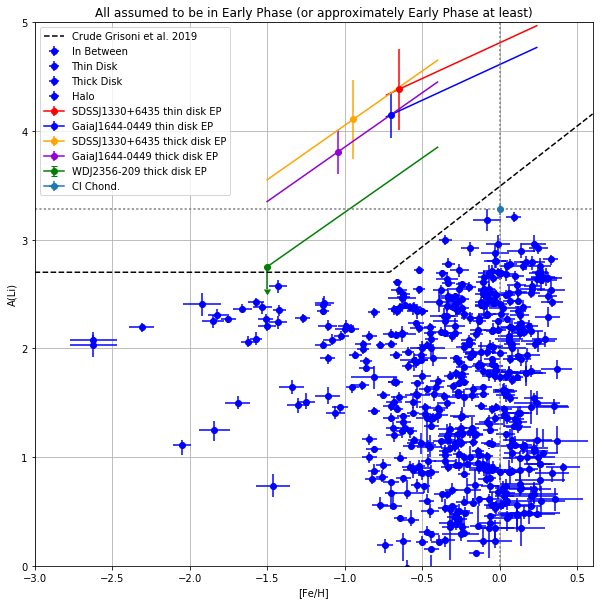

In [56]:
n_random=1000
#j1644_LiCa_dist=make_dist(wd_abund_table.loc['GaiaJ1644-0449']['li/ca'],wd_abund_table.loc['GaiaJ1644-0449']['li/ca_err'], n_random)
#j1330_LiCa_dist=make_dist(wd_abund_table.loc['SDSSJ1330+6435']['li/ca'],wd_abund_table.loc['SDSSJ1330+6435']['li/ca_err'], n_random)
#j1330_LiCa_dist=make_dist(j1330_LiCa_DP,wd_abund_table.loc['SDSSJ1330+6435']['li/ca_err'], n_random)


j1644_LiCa_dist=make_dist(wd_abund_table.loc['GaiaJ1644-0449']['li/ca'],wd_abund_table.loc['GaiaJ1644-0449']['li/ca_err'], n_random)
j1330_LiCa_dist=make_dist(wd_abund_table.loc['SDSSJ1330+6435']['li/ca'],wd_abund_table.loc['SDSSJ1330+6435']['li/ca_err'], n_random)


CaFe_dist=make_dist(get_CaFe_thin(FeH_thin[-1]), 0.1, n_random)
ACa_dist=make_dist(lodders_table.loc['Ca']['A_el'], lodders_table.loc['Ca']['A_el_err'],n_random)


j1330_ALi_vals=wd_abund_table.loc['SDSSJ1330+6435']['li/ca']+(CaFe_thin+FeH_thin)+lodders_table.loc['Ca']['A_el']
j1644_ALi_vals= wd_abund_table.loc['GaiaJ1644-0449']['li/ca']+(CaFe_thin+FeH_thin)+lodders_table.loc['Ca']['A_el']



j1644_ALi_dist=j1644_LiCa_dist+CaFe_dist+FeH_thin[-1]+ACa_dist
j1330_ALi_dist=j1330_LiCa_dist+CaFe_dist+FeH_thin[-1]+ACa_dist
j1644_ALi_err= np.std(j1644_ALi_dist)
j1330_ALi_err= np.std(j1330_ALi_dist)
print(j1644_ALi_err, j1330_ALi_err)

plt.figure(figsize=(10,10))

bp.plot_ALi_FeH()

plt.plot(FeH_thin,j1330_ALi_vals ,  color='r')
plt.errorbar(FeH_thin[8], j1330_ALi_vals[8], yerr=j1330_ALi_err, color='r',label=wd_abund_table.loc['SDSSJ1330+6435']['name']+' thin disk EP',marker='o')


plt.plot(FeH_thin, j1644_ALi_vals,  color='b')
plt.errorbar(FeH_thin[3], j1644_ALi_vals[3], yerr=j1644_ALi_err, color='b',label=wd_abund_table.loc['GaiaJ1644-0449']['name']+' thin disk EP', marker='o')

###########

CaFe_dist=make_dist(CaFe_thick, CaFe_thick_err, n_random)
ACa_dist=make_dist(lodders_table.loc['Ca']['A_el'], lodders_table.loc['Ca']['A_el_err'],n_random)


j1330_ALi_vals=wd_abund_table.loc['SDSSJ1330+6435']['li/ca']+(CaFe_thick+FeH_thick)+lodders_table.loc['Ca']['A_el']
j1644_ALi_vals= wd_abund_table.loc['GaiaJ1644-0449']['li/ca']+(CaFe_thick+FeH_thick)+lodders_table.loc['Ca']['A_el']



j1644_ALi_dist=j1644_LiCa_dist+CaFe_dist+FeH_thick[-1]+ACa_dist
j1330_ALi_dist=j1330_LiCa_dist+CaFe_dist+FeH_thick[-1]+ACa_dist
j1644_ALi_err= np.std(j1644_ALi_dist)
j1330_ALi_err= np.std(j1330_ALi_dist)
print(j1644_ALi_err, j1330_ALi_err)

plt.plot(FeH_thick,j1330_ALi_vals ,  color='orange')
plt.errorbar(FeH_thick[-50], j1330_ALi_vals[-50], label=wd_abund_table.loc['SDSSJ1330+6435']['name']+' thick disk EP',yerr=j1330_ALi_err, color='orange',marker='o')


plt.plot(FeH_thick, j1644_ALi_vals,  color='darkviolet')
plt.errorbar(FeH_thick[-59], j1644_ALi_vals[-59],label=wd_abund_table.loc['GaiaJ1644-0449']['name']+' thick disk EP', yerr=j1644_ALi_err, color='darkviolet', marker='o')


#plt.plot([0,0,0],[4.0,4.6,4.8],linestyle='None', marker='o',label='Solar relations for scaling')
############


#plt.plot(FeH_thin, LiHe_to_ALi(wd_abund_table.loc['SDSSJ1330+6435'], CaFe_thin, FeH_thin, phase='EP'), label=wd_abund_table.loc['SDSSJ1330+6435']['name']+' thin disk EP')
plt.plot(FeH_thick, LiHe_to_ALi(wd_abund_table.loc['WDJ2356-209'], CaFe_thick, FeH_thick, phase='EP'),  color='g')
plt.errorbar(FeH_thick[0], LiHe_to_ALi(wd_abund_table.loc['WDJ2356-209'], CaFe_thick, FeH_thick, phase='EP')[0],label=wd_abund_table.loc['WDJ2356-209']['name']+' thick disk EP',yerr=0.2, uplims=True, color='g', marker='o')
plt.axvline(x=0,linestyle=':', color='grey')
plt.axhline(y=lodders_table.loc['Li']['A_el'],linestyle=':', color='grey')
plt.title('All assumed to be in Early Phase (or approximately Early Phase at least)')
plt.grid(True)
make_plot()

In [57]:
n_random=100000


j1644_LiCa_dist=make_dist(wd_abund_table.loc['GaiaJ1644-0449']['li/ca'],wd_abund_table.loc['GaiaJ1644-0449']['li/ca_err'], n_random)
j1330_LiCa_dist=make_dist(wd_abund_table.loc['SDSSJ1330+6435']['li/ca'],wd_abund_table.loc['SDSSJ1330+6435']['li/ca_err'], n_random)


CaFe_dist=make_dist(CaFe_thick, CaFe_thick_err, n_random)
ACa_dist=make_dist(lodders_table.loc['Ca']['A_el'], lodders_table.loc['Ca']['A_el_err'],n_random)


extreme_j1644=j1644_LiCa_dist+CaFe_dist+FeH_thick[0]+ACa_dist
print("j1644 thick disk most metal poor:",np.mean(extreme_j1644),np.std(extreme_j1644))
extreme_j1330=j1330_LiCa_dist+CaFe_dist+FeH_thick[0]+ACa_dist
print("j1330 thick disk most metal poor:", np.mean(extreme_j1330),np.std(extreme_j1330))
extreme_j2356=wd_abund_table.loc['WDJ2356-209']['li/ca']+CaFe_dist+FeH_thick[0]+ACa_dist
print("j2356 thick disk most metal poor:", np.mean(extreme_j2356),np.mean(extreme_j2356)+3*np.std(extreme_j2356))


j1644 thick disk most metal poor: 3.34993736746 0.193896403102
j1330 thick disk most metal poor: 3.54892449069 0.3664357832
j2356 thick disk most metal poor: 2.74991991925 2.96793033033



extreme_j1644=j1644_LiCa_dist+ACa_dist
print("j1644 solar metallicity:",np.mean(extreme_j1644),np.std(extreme_j1644))
extreme_j1330=j1330_LiCa_dist+ACa_dist
print("j1330 solar metallicity:", np.mean(extreme_j1330),np.std(extreme_j1330))
extreme_j2356=wd_abund_table.loc['WDJ2356-209']['li/ca']+ACa_dist
print("j2356 solar metallicity:", np.mean(extreme_j2356),np.mean(extreme_j2356)+3*np.std(extreme_j2356))



# 2020-04-19 Implementing Chris's edits to the plots

In [58]:
color_dict={
    'GaiaJ1644-0449':'r',
    'SDSSJ1330+6435':'darkviolet',
    'WDJ2356-209':'g'
}
step_dict={
    'GaiaJ1644-0449':10,
    'SDSSJ1330+6435':0.1,
    'WDJ2356-209':10
}

wd_marker='*'
met_marker='D'
met_color='#1ca1f2'
ci_size=14
wd_size=14
dp_alpha=1
arr_naca=[-0.4,-0.1]


star_marker='o'
pop_colors=['darkorange','brown','navy','grey'] #thin disk, thick disk, halo, in-between for Bensby plots

spite_alpha=0.5


In [59]:
#from Mashonkina et al. 2019 and the other Mashonkina et al. 2019/2020 paper that included thin disk stars as well.
npoints=100
FeH_thick= np.linspace(-1.5,-0.4,npoints)
FeH_halo=np.linspace(-2.6,-1.2,npoints)
FeH_thin= np.linspace(-0.73, 0.24, npoints)
#from Mashonkina et al. 2019
CaFe_thick=0.24
CaFe_thick_err=0.07
CaFe_halo=0.35
CaFe_halo_err=0.08

#from later Mashonkina et al. 2019/2020 and our by-eye approximation of the trend
def get_CaFe_thin(FeH):
    slope=(0-0.24)/(0+0.7)
    print(slope)
    return slope*FeH

CaFe_thin=get_CaFe_thin(FeH_thin)

-0.342857142857


In [60]:
def make_plot():
    plt.errorbar(0, lodders_table.loc['Li']['A_el'], yerr=lodders_table.loc['Li']['A_el_err'], xerr= meteor_FeH_err, label='CI Chond.', marker=met_marker,color=met_color, markersize=ci_size)
    model_FeH= np.linspace(-3, 0.6, 100)
    model_ALi= grisoni_crude(model_FeH)
    plt.plot(model_FeH, model_ALi, label='Crude Grisoni et al. 2019', linestyle='--', color='k')
    plt.xlabel('[Fe/H]')
    plt.ylabel('A(Li)')
    #plt.legend(loc='best')
    plt.xlim(-3, 0.6)
    plt.ylim(0,5)
    plt.show()
    return

-0.342857142857
0.214101275747 0.370015689114
B_ALi
-----
 0.03
  0.1
 0.06
 0.06
 0.05
 0.06
 0.05
   --
 0.04
 0.05
  ...
 0.06
 0.04
   --
 0.04
 0.06
   --
 0.04
 0.09
   --
   --
 0.06
Length = 714 rows
<class 'astropy.table.column.MaskedColumn'>
<class 'astropy.table.column.MaskedColumn'>
ALi.shape (714,)
0.195655894569 0.36317840143


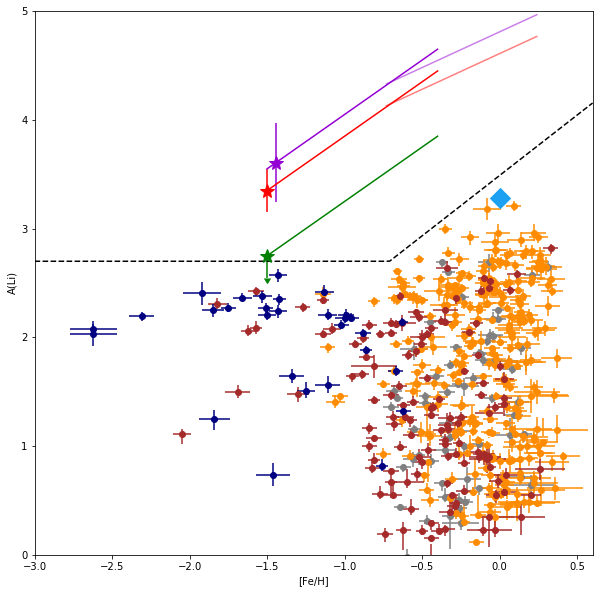

In [61]:
n_random=1000
#j1644_LiCa_dist=make_dist(wd_abund_table.loc['GaiaJ1644-0449']['li/ca'],wd_abund_table.loc['GaiaJ1644-0449']['li/ca_err'], n_random)
#j1330_LiCa_dist=make_dist(wd_abund_table.loc['SDSSJ1330+6435']['li/ca'],wd_abund_table.loc['SDSSJ1330+6435']['li/ca_err'], n_random)
#j1330_LiCa_dist=make_dist(j1330_LiCa_DP,wd_abund_table.loc['SDSSJ1330+6435']['li/ca_err'], n_random)


j1644_LiCa_dist=make_dist(wd_abund_table.loc['GaiaJ1644-0449']['li/ca'],wd_abund_table.loc['GaiaJ1644-0449']['li/ca_err'], n_random)
j1330_LiCa_dist=make_dist(wd_abund_table.loc['SDSSJ1330+6435']['li/ca'],wd_abund_table.loc['SDSSJ1330+6435']['li/ca_err'], n_random)


CaFe_dist=make_dist(get_CaFe_thin(FeH_thin[-1]), 0.1, n_random)
ACa_dist=make_dist(lodders_table.loc['Ca']['A_el'], lodders_table.loc['Ca']['A_el_err'],n_random)


j1330_ALi_vals=wd_abund_table.loc['SDSSJ1330+6435']['li/ca']+(CaFe_thin+FeH_thin)+lodders_table.loc['Ca']['A_el']
j1644_ALi_vals= wd_abund_table.loc['GaiaJ1644-0449']['li/ca']+(CaFe_thin+FeH_thin)+lodders_table.loc['Ca']['A_el']



j1644_ALi_dist=j1644_LiCa_dist+CaFe_dist+FeH_thin[-1]+ACa_dist
j1330_ALi_dist=j1330_LiCa_dist+CaFe_dist+FeH_thin[-1]+ACa_dist
j1644_ALi_err= np.std(j1644_ALi_dist)
j1330_ALi_err= np.std(j1330_ALi_dist)
print(j1644_ALi_err, j1330_ALi_err)

plt.figure(figsize=(10,10))

bp.plot_ALi_FeH(colors=pop_colors, marker=star_marker)

plt.plot(FeH_thin,j1330_ALi_vals ,  color=color_dict['SDSSJ1330+6435'], alpha=spite_alpha)
#plt.errorbar(FeH_thin[8], j1330_ALi_vals[8], yerr=j1330_ALi_err, color='r',label=wd_abund_table.loc['SDSSJ1330+6435']['name']+' thin disk EP',marker='o')


plt.plot(FeH_thin, j1644_ALi_vals,  color=color_dict['GaiaJ1644-0449'], alpha=spite_alpha)
#plt.errorbar(FeH_thin[3], j1644_ALi_vals[3], yerr=j1644_ALi_err, color='b',label=wd_abund_table.loc['GaiaJ1644-0449']['name']+' thin disk EP', marker='o')

###########

CaFe_dist=make_dist(CaFe_thick, CaFe_thick_err, n_random)
ACa_dist=make_dist(lodders_table.loc['Ca']['A_el'], lodders_table.loc['Ca']['A_el_err'],n_random)


j1330_ALi_vals=wd_abund_table.loc['SDSSJ1330+6435']['li/ca']+(CaFe_thick+FeH_thick)+lodders_table.loc['Ca']['A_el']
j1644_ALi_vals= wd_abund_table.loc['GaiaJ1644-0449']['li/ca']+(CaFe_thick+FeH_thick)+lodders_table.loc['Ca']['A_el']



j1644_ALi_dist=j1644_LiCa_dist+CaFe_dist+FeH_thick[-1]+ACa_dist
j1330_ALi_dist=j1330_LiCa_dist+CaFe_dist+FeH_thick[-1]+ACa_dist
j1644_ALi_err= np.std(j1644_ALi_dist)
j1330_ALi_err= np.std(j1330_ALi_dist)
print(j1644_ALi_err, j1330_ALi_err)

plt.plot(FeH_thick,j1330_ALi_vals ,  color=color_dict['SDSSJ1330+6435'])
plt.errorbar(FeH_thick[5], j1330_ALi_vals[5], label=wd_abund_table.loc['SDSSJ1330+6435']['name']+' thick disk EP',yerr=j1330_ALi_err, color=color_dict['SDSSJ1330+6435'],marker=wd_marker, markersize=wd_size)


plt.plot(FeH_thick, j1644_ALi_vals,  color=color_dict['GaiaJ1644-0449'])
plt.errorbar(FeH_thick[0], j1644_ALi_vals[0],label=wd_abund_table.loc['GaiaJ1644-0449']['name']+' thick disk EP', yerr=j1644_ALi_err, color=color_dict['GaiaJ1644-0449'], marker=wd_marker, markersize=wd_size)


#plt.plot([0,0,0],[4.0,4.6,4.8],linestyle='None', marker='o',label='Solar relations for scaling')
############


#plt.plot(FeH_thin, LiHe_to_ALi(wd_abund_table.loc['SDSSJ1330+6435'], CaFe_thin, FeH_thin, phase='EP'), label=wd_abund_table.loc['SDSSJ1330+6435']['name']+' thin disk EP')
plt.plot(FeH_thick, LiHe_to_ALi(wd_abund_table.loc['WDJ2356-209'], CaFe_thick, FeH_thick, phase='EP'),  color=color_dict['WDJ2356-209'])
plt.errorbar(FeH_thick[0], LiHe_to_ALi(wd_abund_table.loc['WDJ2356-209'], CaFe_thick, FeH_thick, phase='EP')[0],label=wd_abund_table.loc['WDJ2356-209']['name']+' thick disk EP',yerr=0.2, uplims=True, color=color_dict['WDJ2356-209'], marker=wd_marker, markersize=wd_size)
#plt.axvline(x=0,linestyle=':', color='grey')
#plt.axhline(y=lodders_table.loc['Li']['A_el'],linestyle=':', color='grey')
#plt.title('All assumed to be in Early Phase (or approximately Early Phase at least)')
#plt.grid(True)
make_plot()

## 2020-06-05 Looking at the CaFe relation... I realized I only obtained a slope, but no actual intercept... so now I'm skeptical of my entire relation...

Therefore, I want to plot it out.

-0.342857142857


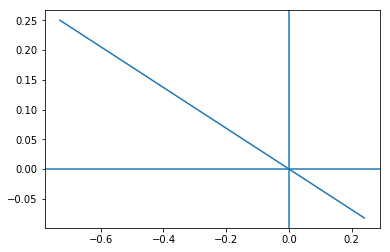

In [62]:
plt.plot(FeH_thin, get_CaFe_thin(FeH_thin))
plt.axvline(x=0)
plt.axhline(y=0)
plt.show()

Oh yeah. Because the relation is in solar normalized units, one only needs a slope because the intercept (or point) is 0,0 by definition of being solar-normalized. I.e. there is an implicit intercept.